Shape: (768, 9)

Class distribution (%):
Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64

Missing values (%):
Pregnancies                  0.0
Glucose                      0.7
BloodPressure                4.6
SkinThickness               29.6
Insulin                     48.7
BMI                          1.4
DiabetesPedigreeFunction     0.0
Age                          0.0
Outcome                      0.0
dtype: float64


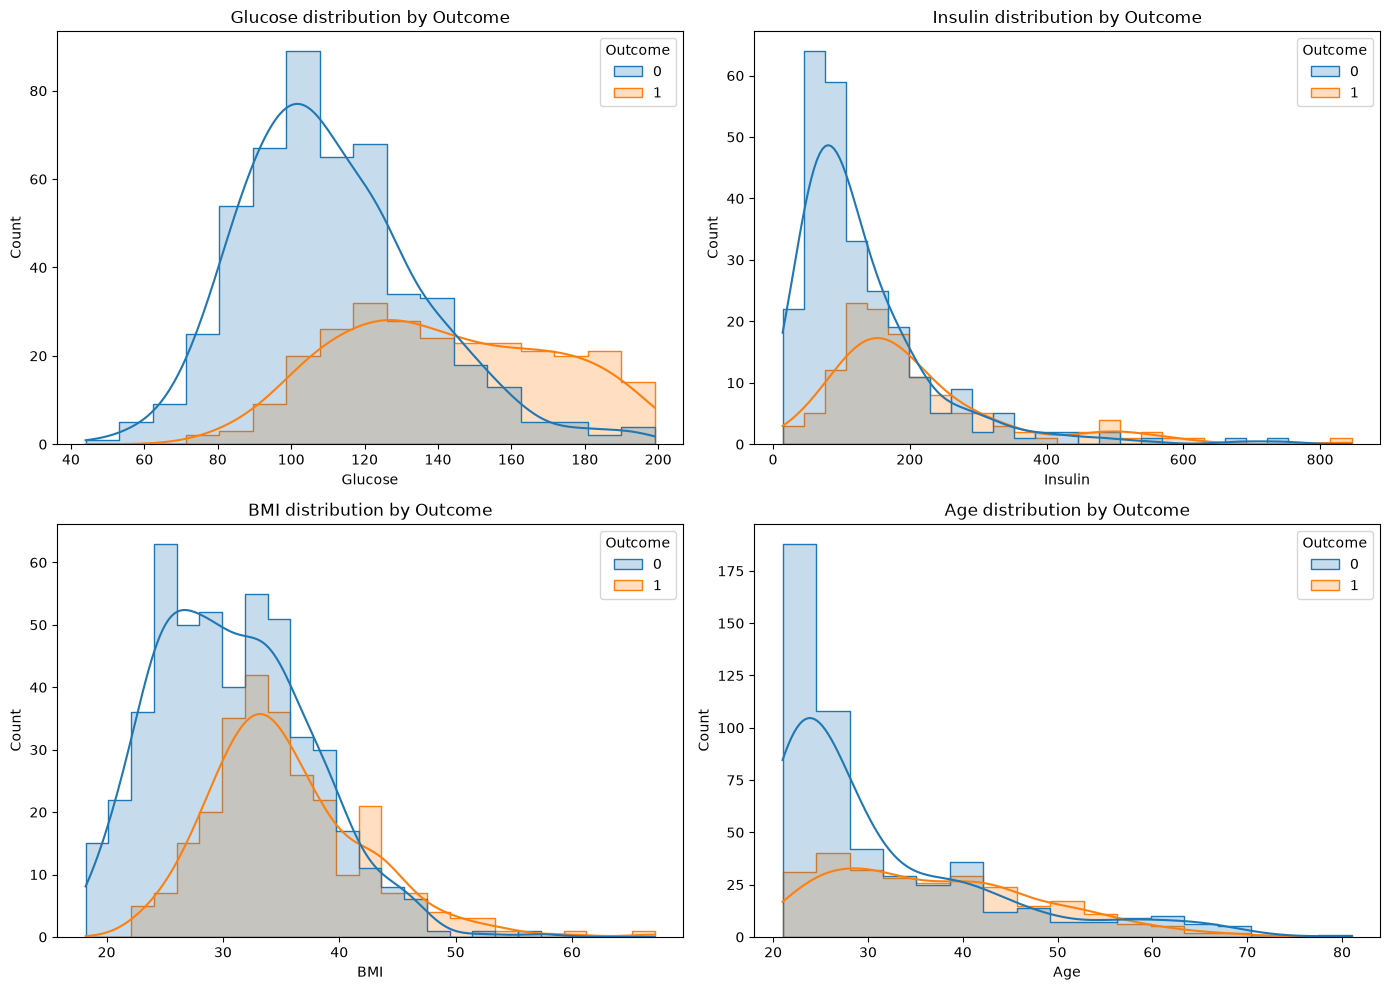


Insulin skewness: raw = 2.166 | log1p = -0.088
Glucose: bounds [36.0, 204.0], outliers: 0
Insulin: bounds [-94.4, 360.6], outliers: 24

Train: (614, 8) | Test: (154, 8)

Missing values after preprocessing (train): 0
Missing values after preprocessing (test):  0

Train mean (~0) and std (~1) after scaling:
      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  BMI  \
mean         -0.0     -0.0            0.0           -0.0     -0.0  0.0   
std           1.0      1.0            1.0            1.0      1.0  1.0   

      DiabetesPedigreeFunction  Age  
mean                      -0.0 -0.0  
std                        1.0  1.0  

Data is ready for modeling!


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

DATA_PATH = '../data/pima-indians-diabetes.csv'
RANDOM_STATE = 42

columns = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
    'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]
df = pd.read_csv(DATA_PATH, names=columns)

cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

print("Shape:", df.shape)
print("\nClass distribution (%):")
print((df['Outcome'].value_counts(normalize=True) * 100).round(2))
print("\nMissing values (%):")
print((df.isna().mean() * 100).round(1))

features = ['Glucose', 'Insulin', 'BMI', 'Age']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat in zip(axes.flatten(), features):
    sns.histplot(data=df, x=feat, hue='Outcome', kde=True, element='step', ax=ax)
    ax.set_title(f'{feat} distribution by Outcome')
plt.tight_layout()
plt.show()

print("\nInsulin skewness: raw =", round(df['Insulin'].skew(), 3),
      "| log1p =", round(np.log1p(df['Insulin']).skew(), 3))

for col in ['Glucose', 'Insulin']:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"{col}: bounds [{lo:.1f}, {hi:.1f}], outliers: {n_out}")

X = df.drop(columns='Outcome')
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("\nTrain:", X_train.shape, "| Test:", X_test.shape)

preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

X_train_prep = pd.DataFrame(
    preprocessor.fit_transform(X_train), columns=X.columns, index=X_train.index
)
X_test_prep = pd.DataFrame(
    preprocessor.transform(X_test), columns=X.columns, index=X_test.index
)

print("\nMissing values after preprocessing (train):", int(X_train_prep.isna().sum().sum()))
print("Missing values after preprocessing (test): ", int(X_test_prep.isna().sum().sum()))
print("\nTrain mean (~0) and std (~1) after scaling:")
print(X_train_prep.agg(['mean', 'std']).round(2))

print("\nData is ready for modeling!")

#### KNN: заполнение пропусков методом K ближайших соседей

#### Что это такое?
KNN Imputer — продвинутый алгоритм импутации, который использует сходство между объектами в датасете для предсказания пропусков.

#### Как работает?
1. Для каждой строки с пропуском (NaN) алгоритм вычисляет "расстояние" до всех остальных строк (обычно Евклидово).
2. Находятся K строк (`n_neighbors=5`), которые находятся ближе всего — это "ближайшие соседи".
3. Пропущенное значение заполняется средним арифметическим значений этого признака у найденных соседей.

#### Почему это лучше простого заполнения средним/медианой?
- Простое заполнение средним игнорирует связи между признаками (например, заполнит инсулин 20-летней и 60-летней одинаково).
- KNN учитывает многомерное пространство признаков: находит похожих пациентов и заполняет пропуск на основе именно их показателей.

#### Важные нюансы
- **Чувствительность к масштабу:** признаки с большим диапазоном (Insulin до 800) доминируют над признаками с малым (Pregnancies до 17). Перед KNN данные желательно масштабировать (`StandardScaler`).
- **Выбор K:** слишком малое K (1) чувствительно к шуму, слишком большое — размывает индивидуальные особенности. Значение 5–7 — стандартный эмпирический выбор.

#### Применение в этом проекте
Применяем импутер только к колонкам `['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']`, потому что нули в них — артефакты сбора данных (медицински невозможные значения). Колонки `Pregnancies` (где 0 — норма) и `Outcome` (целевая переменная) не трогаем, чтобы избежать **data leakage**.